# Lesson 5: Reasoning with images

<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download as"</em> and select <em>"Notebook (.ipynb)"</em>.</p>

<p> 📒 &nbsp; For more help, please see the <em>"Appendix – Tips, Help, and Download"</em> Lesson.</p>

</div>

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different Run Results:</b> The output generated by AI models can vary with each execution due to their dynamic, probabilistic nature. Don't be surprised if your results differ from those shown in the video.</p>

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Slight Changes:</b> To include some very recent changes, the code here varies slightly from that in the video</p>

In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

In [2]:
import json
from openai import OpenAI
from IPython.display import display, Markdown, Image
from helper import get_openai_api_key
openai_api_key = get_openai_api_key()

#from utils import o1_vision

GPT_MODEL = 'gpt-4o-mini'
O1_MODEL = 'o1'

client = OpenAI()

## Process images

We need to process any images into base64 encoding so we can submit them to `o1` with Vision.

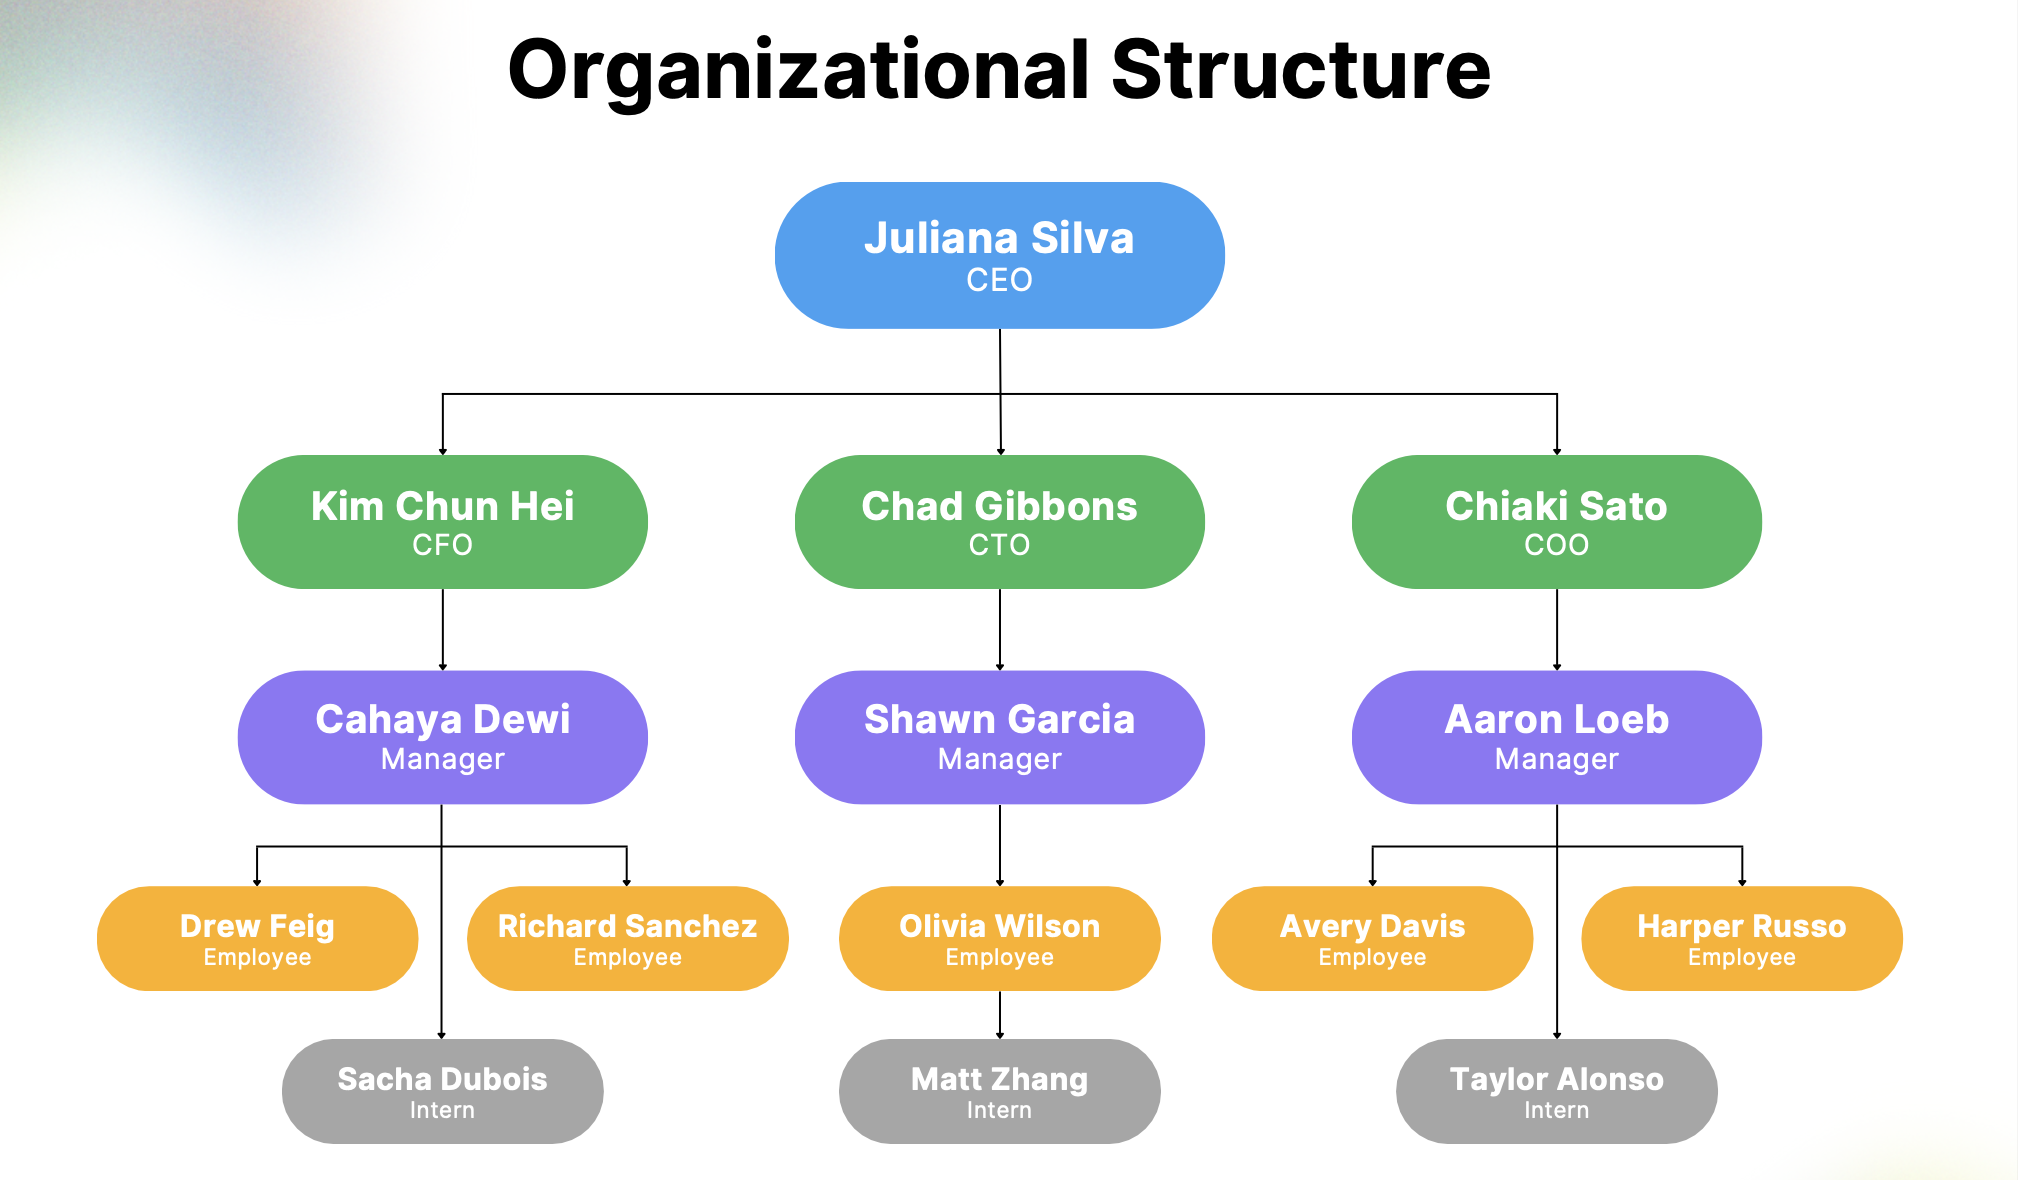

In [3]:
image_filepath = 'data/org_chart_sample.png'

display(Image(image_filepath))

In [4]:
import base64
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

#print(response.choices[0].message.content)

def o1_vision(file_path,prompt,model,json_mode=False):

    base64_image = encode_image(file_path)

    if json_mode:

        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "user", "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {
                        "url": f"data:image/png;base64,{base64_image}"}
                    }
                ]}
            ],
            response_format={ "type": "json_object" }
        )

    else:
        
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "user", "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {
                        "url": f"data:image/png;base64,{base64_image}"}
                    }
                ]}
            ],
        )

    return response


In [5]:
response = o1_vision(file_path=image_filepath
                     ,prompt='What is this?'
                     ,model=O1_MODEL)

In [6]:
display(Markdown(response.choices[0].message.content))

It’s a hierarchical organizational chart showing how different roles (CEO, CFO, CTO, COO, managers, employees, and interns) are structured within a company.

## Image understanding

Where `o1` with Vision shines is in **reasoning** with images - by testing and learning it can identify hallucinations and generally do better than 4o with similar nuanced problems.


In [7]:
structured_prompt = ("<instructions>You are a consulting assistant who processes org data. "
                     "Extract the org hierarchy from the image you're provided in a structured format. "
                     "The structure should be returned in JSON containing:\n"
                     "- arbitrary ID of the person that you can generate\n"
                     "- name of the person\n"
                     "- role of the person\n"
                     "- an array of IDs they report to\n"
                     "- an array of IDs that report to them"
                     "</instructions>")
print(structured_prompt)

<instructions>You are a consulting assistant who processes org data. Extract the org hierarchy from the image you're provided in a structured format. The structure should be returned in JSON containing:
- arbitrary ID of the person that you can generate
- name of the person
- role of the person
- an array of IDs they report to
- an array of IDs that report to them</instructions>


In [8]:
o1_response = o1_vision(file_path=image_filepath
                        ,model='o1'
                        ,prompt=structured_prompt
                        ,json_mode=True)
print(o1_response.choices[0].message.content)

{
  "people": [
    {
      "id": "p1",
      "name": "Juliana Silva",
      "role": "CEO",
      "reportsTo": [],
      "manages": ["p2", "p3", "p4"]
    },
    {
      "id": "p2",
      "name": "Kim Chun Hei",
      "role": "CFO",
      "reportsTo": ["p1"],
      "manages": ["p5"]
    },
    {
      "id": "p3",
      "name": "Chad Gibbons",
      "role": "CTO",
      "reportsTo": ["p1"],
      "manages": ["p6"]
    },
    {
      "id": "p4",
      "name": "Chiaki Sato",
      "role": "COO",
      "reportsTo": ["p1"],
      "manages": ["p7"]
    },
    {
      "id": "p5",
      "name": "Cahaya Dewi",
      "role": "Manager",
      "reportsTo": ["p2"],
      "manages": ["p8", "p9", "p10"]
    },
    {
      "id": "p6",
      "name": "Shawn Garcia",
      "role": "Manager",
      "reportsTo": ["p3"],
      "manages": ["p11", "p12"]
    },
    {
      "id": "p7",
      "name": "Aaron Loeb",
      "role": "Manager",
      "reportsTo": ["p4"],
      "manages": ["p13", "p14", "p15"]
    },


### Analysis

Now that we've extracted the information, we can use it for Q&A.

In [9]:
cleaned_json = o1_response.choices[0].message.content.replace('```json','').replace('```','')

In [10]:
org_data = json.loads(o1_response.choices[0].message.content)
org_data

{'people': [{'id': 'p1',
   'name': 'Juliana Silva',
   'role': 'CEO',
   'reportsTo': [],
   'manages': ['p2', 'p3', 'p4']},
  {'id': 'p2',
   'name': 'Kim Chun Hei',
   'role': 'CFO',
   'reportsTo': ['p1'],
   'manages': ['p5']},
  {'id': 'p3',
   'name': 'Chad Gibbons',
   'role': 'CTO',
   'reportsTo': ['p1'],
   'manages': ['p6']},
  {'id': 'p4',
   'name': 'Chiaki Sato',
   'role': 'COO',
   'reportsTo': ['p1'],
   'manages': ['p7']},
  {'id': 'p5',
   'name': 'Cahaya Dewi',
   'role': 'Manager',
   'reportsTo': ['p2'],
   'manages': ['p8', 'p9', 'p10']},
  {'id': 'p6',
   'name': 'Shawn Garcia',
   'role': 'Manager',
   'reportsTo': ['p3'],
   'manages': ['p11', 'p12']},
  {'id': 'p7',
   'name': 'Aaron Loeb',
   'role': 'Manager',
   'reportsTo': ['p4'],
   'manages': ['p13', 'p14', 'p15']},
  {'id': 'p8',
   'name': 'Drew Feig',
   'role': 'Employee',
   'reportsTo': ['p5'],
   'manages': []},
  {'id': 'p9',
   'name': 'Richard Sanchez',
   'role': 'Employee',
   'reportsTo':

In [11]:
analysis_prompt = ("<instructions>You are an org chart expert assistant. Your role is to"
                   "answer any org chart questions with your org data.</instructions>\n"
                   f"<org_data>{org_data}</org_data>\n")

In [12]:
from helper import get_openai_api_key

openai_api_key = get_openai_api_key()
client = OpenAI(api_key=openai_api_key)

In [13]:
messages = [{
    "role": "user",
    "content": analysis_prompt + "<question>Who has the highest ranking reports, and which manager has the most reports?</question>"
}]

response = client.chat.completions.create(model=O1_MODEL,
                                          messages=messages)

In [14]:
display(Markdown(response.choices[0].message.content))

Juliana Silva (the CEO) has the highest‐ranking direct reports, since her direct reports (CFO, CTO, and COO) are the most senior roles after CEO. Among managers, both Cahaya Dewi (manager of three people) and Aaron Loeb (also manager of three people) tie for having the most direct reports.

## ER Diagram

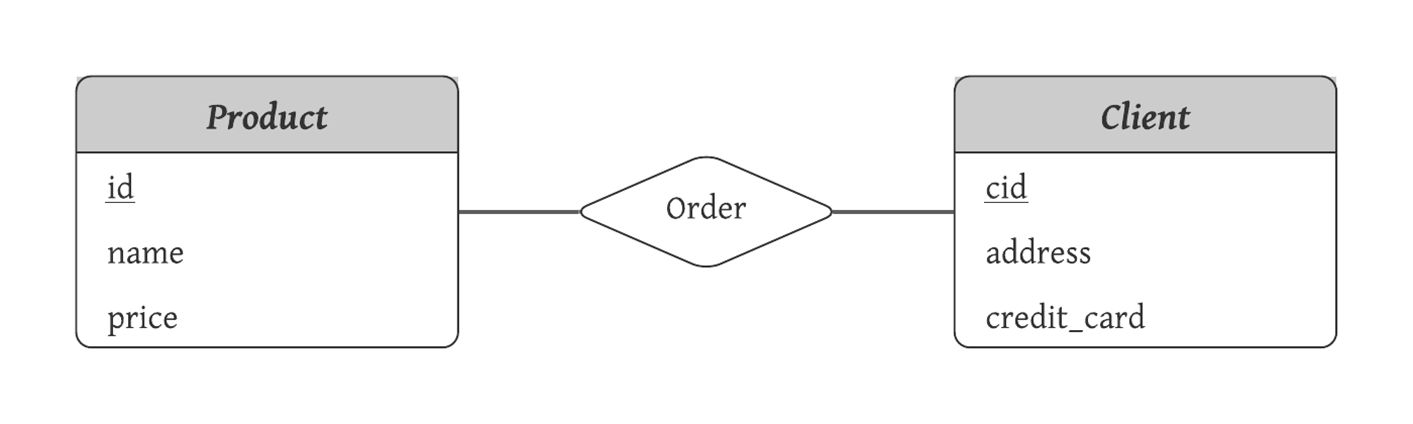

In [15]:
image_filepath = 'data/erd-relation-order.png'

display(Image(image_filepath))